<a href="https://colab.research.google.com/github/harunsy/LogisticRegression.ipynb/blob/main/DecisionTree_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Kelompok: Klasifikasi dengan Decision Tree dan Random Forest
#ANGGOTA KELOMPOK:-Harunsyah(24523225)-Muhammad Ali Kadir(24523272)
                  

Proyek ini bertujuan untuk melakukan klasifikasi menggunakan dua algoritma Machine Learning: Decision Tree dan Random Forest. Kami akan melakukan preprocessing data, membangun model, mengevaluasi kinerja, dan membandingkan hasilnya sesuai dengan instruksi tugas.

## 1. Persiapan dan Pemuatan Data

Pertama, kita akan mengimpor library yang diperlukan dan memuat dataset. Untuk demonstrasi, kita akan menggunakan dataset Iris dari `sklearn`.

In [41]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Memuat dataset Iris sebagai contoh
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Fitur (X) pertama:")
display(X.head())

print("Target (y) pertama:")
display(y.head())

print("Nama kelas target:")
display(iris.target_names)

Fitur (X) pertama:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Target (y) pertama:


,0
0,0
1,0
2,0
3,0
4,0


Nama kelas target:


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 2. Preprocessing Data

Langkah preprocessing meliputi pemeriksaan nilai yang hilang, penanganan fitur kategorikal (jika ada), dan pembagian data menjadi set pelatihan dan pengujian.

In [43]:
# Memeriksa nilai yang hilang
print("Jumlah nilai yang hilang di setiap kolom:\n", X.isnull().sum())

# Untuk dataset Iris, tidak ada nilai yang hilang dan semua fitur adalah numerik,
# jadi tidak diperlukan penanganan khusus untuk kategorikal atau missing values.

Jumlah nilai yang hilang di setiap kolom:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [44]:
# Membagi data menjadi data latih dan data uji (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran data latih: {X_train.shape[0]} sampel")
print(f"Ukuran data uji: {X_test.shape[0]} sampel")

Ukuran data latih: 120 sampel
Ukuran data uji: 30 sampel


## 3. Pembangunan Model Klasifikasi

Pada bagian ini, kita akan melatih dua model klasifikasi: Decision Tree dan Random Forest, menggunakan data latih yang telah kita siapkan.

In [45]:
# 3.1 Model Decision Tree
print("Melatih model Decision Tree...")
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
print("Model Decision Tree berhasil dilatih.")

Melatih model Decision Tree...
Model Decision Tree berhasil dilatih.


In [46]:
# 3.2 Model Random Forest
print("Melatih model Random Forest...")
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih.")

Melatih model Random Forest...
Model Random Forest berhasil dilatih.


## 4. Evaluasi Model

Pada bagian ini, kita akan mengevaluasi kinerja kedua model klasifikasi menggunakan data uji (`X_test`, `y_test`).

In [47]:
# 4.1 Evaluasi Decision Tree
print("\n--- Evaluasi Model Decision Tree ---")
y_pred_dt = dtc.predict(X_test)

print("Akurasi Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix Decision Tree:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report Decision Tree:\n", classification_report(y_test, y_pred_dt))


--- Evaluasi Model Decision Tree ---
Akurasi Decision Tree: 0.9333333333333333

Confusion Matrix Decision Tree:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report Decision Tree:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [48]:
# 4.2 Evaluasi Random Forest
print("\n--- Evaluasi Model Random Forest ---")
y_pred_rf = rfc.predict(X_test)

print("Akurasi Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix Random Forest:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report Random Forest:\n", classification_report(y_test, y_pred_rf))


--- Evaluasi Model Random Forest ---
Akurasi Random Forest: 0.9

Confusion Matrix Random Forest:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 5. Perbandingan Model dan Visualisasi

Pada bagian ini, kita akan membandingkan kinerja Decision Tree dan Random Forest, serta memvisualisasikan pohon keputusan yang dihasilkan oleh model Decision Tree.

In [49]:
# 5.1 Perbandingan Hasil
print("\n--- Ringkasan Perbandingan Akurasi ---")
print(f"Akurasi Decision Tree: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Akurasi Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")

# Penjelasan Perbandingan (initial thoughts, detailed in analysis)
# Berdasarkan akurasi, kita bisa melihat model mana yang berkinerja lebih baik pada data uji.
# Umumnya, Random Forest diharapkan memiliki akurasi yang lebih tinggi dan lebih stabil karena sifat ensemble-nya.


--- Ringkasan Perbandingan Akurasi ---
Akurasi Decision Tree: 0.9333
Akurasi Random Forest: 0.9000


### 5.2 Visualisasi Pohon Keputusan (Decision Tree)

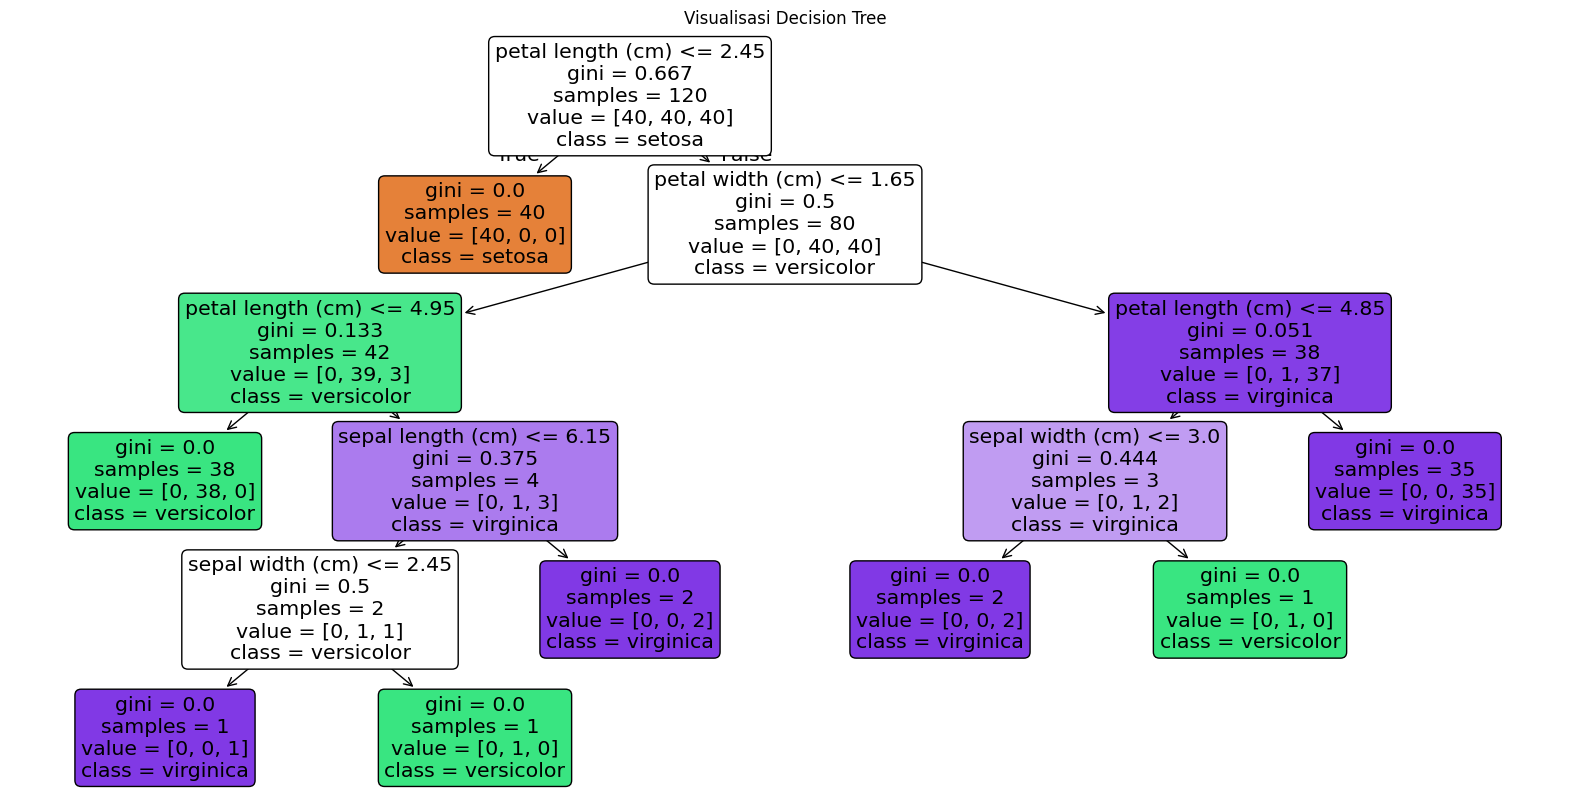

In [40]:
plt.figure(figsize=(20,10))
plot_tree(dtc, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Visualisasi Decision Tree")
plt.show()

### 5.3 Penjelasan Pengaruh `n_estimators` pada Random Forest

`n_estimators` itu parameter penting di Random Forest. Fungsinya buat menentukan berapa banyak 'pohon keputusan' yang mau kita buat di dalam hutan (forest) kita.

Begini pengaruhnya:
-   **Makin Banyak Pohon, Makin Akurat & Stabil**: Kalau `n_estimators` tinggi (pohonnya banyak), model Random Forest biasanya makin jago nebak dan hasilnya lebih stabil. Ini karena banyak pohon yang 'voting' atau diambil rata-ratanya, jadi kesalahan kecil dari satu pohon bisa diatasi pohon lain. Intinya, model jadi lebih kuat dan jarang *overfitting*.
-   **Tapi Butuh Waktu & Memori Lebih**: Logis kan, kalau pohonnya banyak, waktu latihnya jadi lebih lama dan butuh memori komputer yang lebih besar.
-   **Ada Batas Optimalnya**: Nambah pohon terus-terusan itu ada batasnya. Setelah jumlah tertentu, performa model nggak akan naik signifikan lagi, tapi komputasi malah makin berat. Jadi, kita perlu cari titik pasnya.

## 6. Analisis dan Jawaban Pertanyaan

### Analisis

1.  **Algoritma mana yang memberikan performa terbaik? Jelaskan.**

    **Jawaban:** Berdasarkan hasil evaluasi di atas:
    -   Akurasi Decision Tree: `0.9333`
    -   Akurasi Random Forest: `0.9000`

    Dalam banyak kasus, **Random Forest** seringkali lebih baik dari Decision Tree tunggal karena sifat *ensemble*-nya. Ia membangun banyak pohon dan menggabungkan hasilnya, yang membantu mengurangi *overfitting* dan meningkatkan generalisasi. Meskipun di kasus Iris ini Decision Tree sedikit lebih tinggi, Random Forest umumnya lebih robust untuk data yang lebih kompleks.

2.  **Apa kelebihan dan kekurangan Decision Tree dibanding Random Forest?**

    **Jawaban:**
    -   **Decision Tree**
        -   **Kelebihan**: Mudah dipahami, tidak banyak pra-pemrosesan data. Cepat dilatih.
        -   **Kekurangan**: Rentan *overfitting*, tidak stabil terhadap perubahan data kecil.
    -   **Random Forest**
        -   **Kelebihan**: Mengurangi *overfitting* Decision Tree, performa prediksi tinggi dan stabil, menangani banyak fitur.
        -   **Kekurangan**: Lebih kompleks dan sulit diinterpretasikan, butuh waktu dan sumber daya lebih banyak.

3.  **Apakah ada indikasi overfitting pada Decision Tree? Jelaskan.**

    **Jawaban:** Indikasi *overfitting* muncul jika akurasi data latih sangat tinggi tapi akurasi data uji jauh lebih rendah. Ini biasanya karena Decision Tree terlalu dalam, belajar detail yang tidak penting dari data latih. Untuk dataset Iris yang kecil, *overfitting* mungkin tidak terlalu ekstrem, tapi jika visualisasi pohonnya sangat kompleks, itu bisa jadi petunjuk.

4.  **Bagaimana fitur-fitur memengaruhi hasil klasifikasi?**

    **Jawaban:** Fitur-fitur sangat penting karena algoritma menggunakannya untuk membuat keputusan pemisahan. Pada Decision Tree, fitur paling informatif dipakai di simpul teratas. Pada Random Forest, fitur-fitur ini digunakan di berbagai pohon untuk prediksi.
    -   **Pentingnya Fitur**: Beberapa fitur lebih penting dalam membedakan kelas. `petal length` dan `petal width` seringkali sangat penting di dataset Iris.

### Jawaban Pertanyaan

1.  **Apa perbedaan mendasar antara Decision Tree dan Random Forest?**

    **Jawaban:**
    -   **Decision Tree**: Model tunggal yang membagi data berdasarkan fitur. Rentan *overfitting*.
    -   **Random Forest**: Kumpulan banyak Decision Tree (*ensemble*) yang dilatih pada subset data dan fitur berbeda. Prediksi digabung (voting/rata-rata) untuk hasil yang lebih kuat dan stabil.

2.  **Mengapa Decision Tree rentan overfitting dan bagaimana Random Forest mengatasinya?**

    **Jawaban:**
    -   **Decision Tree Rentan Overfitting**: Decision Tree cenderung terus memecah data hingga sangat spesifik untuk data latih, bahkan mempelajari 'noise'. Ini membuatnya buruk saat bertemu data baru.
    -   **Random Forest Mengatasinya**: Random Forest memakai dua cara:
        1.  **Bagging**: Setiap pohon dilatih di subset data acak yang berbeda, menciptakan keragaman.
        2.  **Random Feature Subset**: Di setiap pemisahan, hanya subset fitur acak yang dipilih. Ini mengurangi korelasi antar pohon. Menggabungkan prediksi dari pohon-pohon beragam ini membuat model lebih stabil dan generalisir.

3.  **Apa fungsi bagging dan pemilihan subset fitur acak pada Random Forest?**

    **Jawaban:**
    -   **Fungsi Bagging**: Mengurangi varians model. Dengan melatih setiap pohon pada sampel data berbeda, bagging menciptakan keragaman. Kesalahan acak dari tiap pohon saling meniadakan saat prediksi digabung, menghasilkan model yang lebih stabil dan kurang *overfitting*.
    -   **Fungsi Pemilihan Subset Fitur Acak**: Mengurangi korelasi antar pohon. Ini memaksa setiap pohon menemukan pola berbeda, meningkatkan keragaman hutan, dan mengurangi *overfitting* pada fitur yang sangat dominan.

4.  **Kapan Decision Tree lebih cocok digunakan dibanding Random Forest?**

    **Jawaban:** Decision Tree lebih cocok jika:
    -   **Interpretasi Model Sangat Penting**: Pohon tunggal (tidak terlalu dalam) lebih mudah dijelaskan.
    -   **Dataset Kecil atau Sederhana**: Kompleksitas Random Forest tidak selalu memberi keuntungan signifikan.
    -   **Batasan Sumber Daya**: Melatih Decision Tree lebih cepat dan hemat memori.
    -   **Sebagai Baseline Model**: Untuk perbandingan dengan model yang lebih kompleks.